# Day 1A — Machine Learning Foundations with NumPy, SciPy, and scikit-learn

This self-contained introduction uses **fictional industrial sensor data**. It exposes the mechanics
instead of hiding them behind tuning helpers: regression, classification, regularization, manual
hyperparameter search, evaluation, and several model families.

## 1. Samples, features, targets, and honest evaluation

$X\in\mathbb{R}^{n\times p}$ contains one sample per row and one feature per column; $y$ contains
the desired outputs. Training selects model parameters $\theta$ by minimizing a loss.

| Subset | Job | Learn weights? | Choose hyperparameters? |
|---|---|---:|---:|
| Train | Fit model and preprocessing | Yes | Indirectly |
| Validation | Compare candidates | No | Yes |
| Test | One final unbiased estimate | No | No |

Scaling, imputation, and feature selection are learned operations too. Fit them on training data.
Use grouped or temporal splits for repeated devices, people, batches, or time series; the random split
below is suitable only because these fictional rows are independent.

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import ParameterGrid
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# One seed makes every generated dataset and split reproducible.
SEED=42
rng=np.random.default_rng(SEED)

## 2. Fictional nonlinear data; split first and scale second

Each row represents a process state and the target is a fictitious concentration. In a real project,
replace this generation step with data loading and validation. Training means and standard deviations
are stored and reused for validation, test, and future production samples—never recomputed per set.

In [2]:
# Generate five fictional inputs with deliberately different scales.
n=900
t=rng.uniform(15,45,n); h=rng.uniform(20,85,n); a=rng.normal(size=n)
b=.65*a+rng.normal(0,.65,n); age=rng.uniform(0,1,n)
# The target combines linear, nonlinear, and noisy contributions.
X=np.column_stack([t,h,a,b,age]); y=8+.45*t-.08*h+4*a+2.5*b**2-5*age+2*np.sin(a)+rng.normal(0,1.8,n)
# Split before learning any preprocessing statistics.
order=rng.permutation(n); nt,nv=int(.6*n),int(.2*n); it,iv,ix=order[:nt],order[nt:nt+nv],order[nt+nv:]
X_train,y_train=X[it],y[it]; X_val,y_val=X[iv],y[iv]; X_test,y_test=X[ix],y[ix]
# Learn scaling values from training rows only.
x_mean,x_std=X_train.mean(0),X_train.std(0); x_std[x_std==0]=1
Xs_train=(X_train-x_mean)/x_std; Xs_val=(X_val-x_mean)/x_std; Xs_test=(X_test-x_mean)/x_std
print("features:",["temperature","humidity","sensor_a","sensor_b","sensor_age"])
print("first sample and target:",X[0],y[0])

features: ['temperature', 'humidity', 'sensor_a', 'sensor_b', 'sensor_age']
first sample and target: [3.82186815e+01 5.04470817e+01 2.26764420e+00 8.56120198e-01
 3.02099482e-02] 32.6870140930183


## 3. Baseline, metrics, and SciPy optimization

MAE is directly interpretable; RMSE emphasizes large misses; $R^2=0$ matches a mean predictor.
We add an intercept column and minimize $n^{-1}\sum_i(y_i-X_iw)^2$. SciPy knows only the objective
we provide, making the same pattern useful for custom empirical or physics-informed models.

In [3]:
def metrics(actual,predicted):
    # Visible formulas connect the code to MAE, RMSE, and R² definitions.
    e=np.asarray(actual)-np.asarray(predicted)
    return {"MAE":np.mean(abs(e)),"RMSE":np.sqrt(np.mean(e**2)),"R2":1-np.sum(e**2)/np.sum((actual-np.mean(actual))**2)}
def design(values): return np.column_stack([np.ones(len(values)),values])
def mse(weights,X,y): return np.mean((y-X@weights)**2)
Xd_train,Xd_val=design(Xs_train),design(Xs_val)
print("mean baseline:",metrics(y_val,np.full_like(y_val,y_train.mean())))
# SciPy repeatedly calls mse() while changing the candidate weights.
fit=minimize(mse,np.zeros(Xd_train.shape[1]),args=(Xd_train,y_train),method="BFGS")
print("linear model:",metrics(y_val,Xd_val@fit.x))

mean baseline: {'MAE': np.float64(6.072661773564823), 'RMSE': np.float64(7.683530225236206), 'R2': np.float64(-0.0040322312761849055)}
linear model: {'MAE': np.float64(2.4692947750033127), 'RMSE': np.float64(3.4253766247891835), 'R2': np.float64(0.8004541472550263)}


## 4. The same regression with standard scikit-learn estimators

In normal projects, prefer tested estimators unless the objective is genuinely custom. They share a
simple interface: `fit(X, y)` learns parameters and `predict(X)` applies them. `Ridge` implements L2
regularization through `alpha`; `Lasso` implements L1. Our features are already standardized, so the
penalties act on comparable scales.

In [4]:
# Define unfitted candidate estimators.
sklearn_models = {
    "ordinary linear regression": LinearRegression(),
    "ridge (L2)": Ridge(alpha=1.0),
    "lasso (L1)": Lasso(alpha=0.05, max_iter=10_000),
}

# Fit on training data and compare on validation data.
sklearn_scores = []
for model_name, model in sklearn_models.items():
    model.fit(Xs_train, y_train)
    validation_prediction = model.predict(Xs_val)
    sklearn_scores.append({"model": model_name, **metrics(y_val, validation_prediction)})

sorted(sklearn_scores, key=lambda row: row["RMSE"])

[{'model': 'ordinary linear regression',
  'MAE': np.float64(2.4692945146296705),
  'RMSE': np.float64(3.4253764055129556),
  'R2': np.float64(0.8004541728029676)},
 {'model': 'ridge (L2)',
  'MAE': np.float64(2.469179126261979),
  'RMSE': np.float64(3.4257258731870377),
  'R2': np.float64(0.8004134541401814)},
 {'model': 'lasso (L1)',
  'MAE': np.float64(2.469807356764374),
  'RMSE': np.float64(3.426394323071969),
  'R2': np.float64(0.8003355572944806)}]

## 5. L1/L2 regularization inside a custom loss

$$J(w)=\operatorname{MSE}(w)+\lambda_1\sum_{j=1}^{p}|w_j|+\lambda_2\sum_{j=1}^{p}w_j^2.$$

L1 promotes sparsity; L2 smoothly shrinks correlated coefficients. The intercept is excluded and a
smooth absolute value helps gradient optimization near zero. We fit every candidate on train and
rank it on validation. This remains useful when no standard estimator represents the required loss.

In [5]:
def objective(w,X,y,l1=0.,l2=0.):
    # weights[0] is the intercept, so only feature coefficients are penalized.
    coefficients=w[1:]
    return np.mean((y-X@w)**2)+l1*np.sum(np.sqrt(coefficients**2+1e-10))+l2*np.sum(coefficients**2)
# Explicit grid search: train on train, rank on validation, never touch test.
rows=[]
for l1,l2 in itertools.product([0,.01,.05,.2],[0,.05,.2,1.]):
    fitted=minimize(objective,np.zeros(Xd_train.shape[1]),args=(Xd_train,y_train,l1,l2),method="L-BFGS-B")
    rows.append({"l1":l1,"l2":l2,"validation_RMSE":metrics(y_val,Xd_val@fitted.x)["RMSE"]})
search=sorted(rows,key=lambda row:row["validation_RMSE"]); search[:8]

[{'l1': 0.01, 'l2': 0, 'validation_RMSE': np.float64(3.425361150541857)},
 {'l1': 0, 'l2': 0, 'validation_RMSE': np.float64(3.425376446856219)},
 {'l1': 0.05, 'l2': 0, 'validation_RMSE': np.float64(3.425564328276447)},
 {'l1': 0.2, 'l2': 0, 'validation_RMSE': np.float64(3.4300877765150504)},
 {'l1': 0, 'l2': 0.05, 'validation_RMSE': np.float64(3.448485076052998)},
 {'l1': 0.01, 'l2': 0.05, 'validation_RMSE': np.float64(3.4490449309531925)},
 {'l1': 0.05, 'l2': 0.05, 'validation_RMSE': np.float64(3.4515265573821114)},
 {'l1': 0.2, 'l2': 0.05, 'validation_RMSE': np.float64(3.4642695272910946)}]

## 6. Data preprocessing and a complete scikit-learn `Pipeline`

Real data often contain missing readings and differently scaled features. A pipeline chains all
steps into one safe object:

1. `SimpleImputer` learns training-column medians and fills missing values;
2. `StandardScaler` learns training means and scales;
3. `Ridge` learns regression coefficients.

`fit` learns each step in order. `predict` reuses the stored transformations before prediction.
This prevents leakage and guarantees identical preprocessing during training and inference.

In [6]:
# Simulate a realistic preprocessing problem without changing the clean example above.
X_with_missing = X.copy()
missing_rng = np.random.default_rng(123)
X_with_missing[missing_rng.random(X_with_missing.shape) < 0.03] = np.nan

# Reuse the original indices; the pipeline receives raw, unscaled arrays with NaNs.
X_raw_train = X_with_missing[it]
X_raw_val = X_with_missing[iv]

ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge()),
])

# Pipeline parameters use step__parameter names. ParameterGrid creates combinations;
# our loop keeps the train/validation logic visible instead of using GridSearchCV.
pipeline_results = []
for parameters in ParameterGrid({"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}):
    ridge_pipeline.set_params(**parameters)
    ridge_pipeline.fit(X_raw_train, y_train)
    prediction_val = ridge_pipeline.predict(X_raw_val)
    pipeline_results.append({**parameters, "validation_RMSE": metrics(y_val, prediction_val)["RMSE"]})

sorted(pipeline_results, key=lambda row: row["validation_RMSE"])

[{'model__alpha': 10.0, 'validation_RMSE': np.float64(3.599294824958428)},
 {'model__alpha': 1.0, 'validation_RMSE': np.float64(3.600202391752676)},
 {'model__alpha': 0.1, 'validation_RMSE': np.float64(3.6005162089458276)},
 {'model__alpha': 0.01, 'validation_RMSE': np.float64(3.600549983702451)},
 {'model__alpha': 100.0, 'validation_RMSE': np.float64(3.717161040253916)}]

## 7. Refit the frozen custom model and open the test set once

After selection, train and validation become one development set. Scaling is relearned on that set,
the frozen configuration is refitted, and the test set is evaluated exactly once. Repeated changes
after reading test results silently turn the test set into validation data.

selected: {'l1': 0.01, 'l2': 0} | test: {'MAE': np.float64(2.454443301396811), 'RMSE': np.float64(3.3080935375213967), 'R2': np.float64(0.80189499866427)}


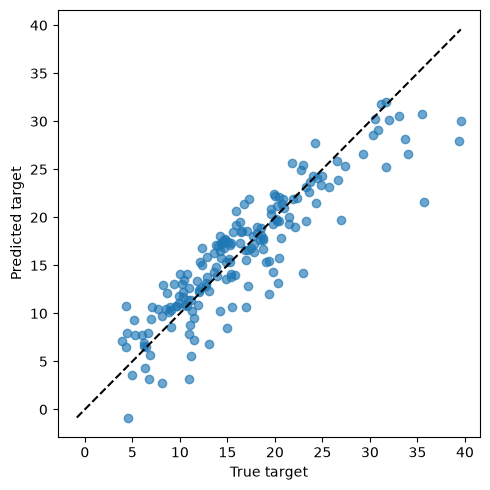

In [7]:
# Freeze the validation winner before using any test rows.
best=search[0]; X_dev=np.vstack([X_train,X_val]); y_dev=np.r_[y_train,y_val]
# Relearn preprocessing on all available development data.
mean_dev,std_dev=X_dev.mean(0),X_dev.std(0); std_dev[std_dev==0]=1
Xd_dev=design((X_dev-mean_dev)/std_dev); Xd_test=design((X_test-mean_dev)/std_dev)
final=minimize(objective,np.zeros(Xd_dev.shape[1]),args=(Xd_dev,y_dev,best["l1"],best["l2"]),method="L-BFGS-B")
prediction=Xd_test@final.x
print("selected:",{"l1":best["l1"],"l2":best["l2"]},"| test:",metrics(y_test,prediction))
plt.figure(figsize=(5,5)); plt.scatter(y_test,prediction,alpha=.65)
limits=[min(y_test.min(),prediction.min()),max(y_test.max(),prediction.max())]
plt.plot(limits,limits,"k--"); plt.xlabel("True target"); plt.ylabel("Predicted target"); plt.tight_layout()

## 8. Classification: custom loss and scikit-learn

`High concentration` is defined by the **training median only**. Logistic regression models
$p(y=1|x)=\sigma(Xw)$ and minimizes binary cross-entropy. `logaddexp` is a stable implementation.
Accuracy may hide imbalance, so precision and recall are included. We then fit scikit-learn's
`LogisticRegression`, the standard equivalent with built-in L2 regularization.

In [8]:
# Derive the threshold from training targets only.
threshold=np.median(y_train); c_train=(y_train>threshold).astype(float); c_val=(y_val>threshold).astype(int)
def logistic_loss(w,X,y,l2):
    logits=X@w
    return np.mean(np.logaddexp(0,logits)-y*logits)+l2*np.sum(w[1:]**2)
classifier=minimize(logistic_loss,np.zeros(Xd_train.shape[1]),args=(Xd_train,c_train,.1),method="BFGS")
pred=expit(Xd_val@classifier.x)>=.5; tp=np.sum(pred&(c_val==1)); fp=np.sum(pred&(c_val==0)); fn=np.sum(~pred&(c_val==1))
print("custom:",{"accuracy":np.mean(pred==c_val),"precision":tp/max(tp+fp,1),"recall":tp/max(tp+fn,1)})

# C is inverse regularization strength: smaller C means stronger L2 regularization.
sklearn_classifier = LogisticRegression(C=1.0, max_iter=2_000)
sklearn_classifier.fit(Xs_train, c_train)
print("scikit-learn validation accuracy:", sklearn_classifier.score(Xs_val, c_val))

custom: {'accuracy': np.float64(0.8777777777777778), 'precision': np.float64(0.8947368421052632), 'recall': np.float64(0.8762886597938144)}
scikit-learn validation accuracy: 0.8888888888888888


## 9. Other model families under the same protocol

k-NN predicts from nearby stored samples; random forests average many trees; an RBF support-vector
regressor represents a smooth nonlinear relation. The library fits parameters, but our loop controls
the candidates and protects the test set.

In [9]:
# All candidates receive the same preprocessed training and validation arrays.
candidates={"kNN-5":KNeighborsRegressor(5,weights="distance"),"kNN-15":KNeighborsRegressor(15,weights="distance"),
            "forest":RandomForestRegressor(n_estimators=150,max_depth=8,random_state=SEED),"RBF-SVR":SVR(C=10)}
comparison=[]
for name,model in candidates.items():
    model.fit(Xs_train,y_train); comparison.append({"model":name,**metrics(y_val,model.predict(Xs_val))})
sorted(comparison,key=lambda row:row["RMSE"])

[{'model': 'RBF-SVR',
  'MAE': np.float64(1.743223980470805),
  'RMSE': np.float64(2.2863538077408023),
  'R2': np.float64(0.9110977154740765)},
 {'model': 'forest',
  'MAE': np.float64(1.9948531572692483),
  'RMSE': np.float64(2.488093985159348),
  'R2': np.float64(0.8947166708314847)},
 {'model': 'kNN-5',
  'MAE': np.float64(2.243340811741496),
  'RMSE': np.float64(2.940766790200424),
  'R2': np.float64(0.8529221687869329)},
 {'model': 'kNN-15',
  'MAE': np.float64(2.318611019006263),
  'RMSE': np.float64(3.0382824937506716),
  'R2': np.float64(0.8430062550888735)}]

## 10. Checklist and exercises

Define the future prediction scenario; validate units, ranges, labels, duplicates, and groups; design
the split before tuning; fit preprocessing on train only; establish a baseline; tune on validation or
cross-validation; test the frozen pipeline once; save preprocessing with the model; monitor drift.

Exercises: add polynomial features manually, implement grouped folds, plot coefficient paths, or
sample lambdas randomly from log-uniform distributions.